# INF2008 Group Project (Stage 2)
By: Group 25 Lab P2

This notebook documents Stage 2 of the INF2008 Group Machine Learning Project, continuing from Stage 1 under the CRISP-DM methodology. It covers the following phases:
1) Advanced Data Preparation and Pipeline Engineering
2) Champion Model Selection
3) Controlled Ablations and Tuning
4) Mechanical Failure Analysis
5) Decision Making
6) Final Evaluation on Hold-out Test Set

Building on the baseline established in Stage 1, the focus of this stage shifts toward pipeline engineering, rigorous model selection via cross-validation, and controlled experimentation. A champion model is selected from a comparison of distinct algorithmic families, then subjected to targeted ablation studies. The stage concludes with a mechanical inspection of model failures, a business-grounded justification for threshold adjustment, and a single final evaluation of the tuned champion on the held-out test set.

In [28]:
import numpy as np
import pandas as pd
from collections import Counter

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    TargetEncoder,
)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt

### 1. Advanced Data Preparation & Pipeline Engineering

Stage 1 completed a minimal version of CRISP-DM Phase 3 (Data Preparation):
- Duplicates were removed (12 rows)
- Dropped `duration` (data leakage)
- Replaced `pdays` with binary flag `was_previously_contacted`
- Cleaned trailing dot from `admin.` in `job`
- Converted `month` to numeric (1-12)
- Binary encoded `y` and `contact`
- One-hot encoded nominal categorical columns

However, there were a few problems with Stage 1's approach that this section fixes.

**Problem 1: Existing Data Leakage**

In Stage 1, preprocessing steps like encoding were applied to the entire dataset before splitting it into training and test sets. This results in **data leakage** as the preprocessing got to "see" the test data while it was being set up.

The Fix: Use a Pipeline where a chain of processing steps are bundled together as a single object. The key property of a pipeline is that its steps are only allowed to learn from the training data. When the pipeline is later applied to new or test data, it uses those already-learned values without looking at the new data again.

**Problem 2: No Feature Scaling**

Stage 1 applied no feature scaling to numeric columns. Without scaling, a column like `nr.employed` (values around 5,000) has thousands of times more numerical influence than `previous` (values of 0-7), even if `previous` is actually more informative. Some models, like Logistic Regression, are directly affected by this. Even tree-based models benefit from consistent input scales when used alongside other techniques.

The Fix: Use **RobustScaler** to rescale each numeric column to a consistent range using median and IQR.

**Problem 3: No Treatment for Class Imbalance**

Stage 1 made no attempt to address the class imbalance in the dataset. To help the model learn the minority class ("yes") properly, the training data needs to be rebalanced.

The Fix: Use **SMOTE** (Synthetic Minority Oversampling Technique) to generate new artificial training examples for the minority class ("yes") by interpolating between existing "yes" examples, giving the model more to learn from without simply duplicating rows.

**Problem 4: Encoding Strategy Limitation**

Stage 1 applied one-hot encoding to all categorical columns, including high-cardinality ones like `job` (12 values), `education` (8 values), and `month` (10 values). One-hot encoding creates one binary column per unique value, so a column with 12 values becomes 12 separate columns, most of which are mostly zeros and carry little individual signal.

The Fix: Use **TargetEncoder** to replace each category label with the average subscription rate for that label in the training data. For example, if 30% of students subscribed and only 5% of blue-collar workers did, "student" becomes 0.30 and "blue-collar" becomes 0.05. This reduces each high-cardinality column to a single informative number instead of many sparse binary columns.

**Problem 5: Conservative Stance on `'unknown'` Values**

Stage 1 found no explicit missing values (NaN) in the dataset. However, several columns contain `'unknown'` as a string, accounting for roughly 26% of rows. Stage 1 kept these as a distinct category on the basis that they could carry meaningful signal. Stage 2 takes a different stance: `'unknown'` most likely reflects incomplete data collection on the bank's side (the field simply wasn't recorded), rather than a true distinct client state. Under this assumption, treating `'unknown'` as missing data and filling it in with the most common value from the training set is more appropriate for a predictive pipeline. However, this is just an assumption. Whether it helps or hurts will be tested later on.

The Fix: Convert `'unknown'` strings to `NaN` and fill them via **SimpleImputer** which uses statistics learned from the training set (the median for numeric columns, the most common category for categorical columns)

##### 1.1 Loading Raw Data

Stage 2 starts from `data/raw/bank-additional-full.csv` rather than the processed files from Stage 1. This is because the Stage 1 processed files had one-hot encoding applied to the entire dataset before splitting. Loading those files would carry the leakage forward.

By starting from the raw CSV and putting all encoding steps inside the pipeline, we ensure that the encoder only ever fits on training data.

In [29]:
df = pd.read_csv('data/raw/bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


##### 1.2 Pre-Pipeline Cleaning

Not every preprocessing step needs to live inside the pipeline. A step can be applied before the pipeline if and only if it is **fully deterministic**, meaning it does not compute any statistic from the data, and it would give the exact same result regardless of which rows it sees.

The table below lists what is done outside the pipeline and why it is safe to do so:

| Operation | Why it is safe |
|---|---|
| Drop duplicate rows | Just compares rows, learns nothing from the data |
| Drop `duration` column | A fixed schema decision, not data-dependent |
| Encode `y` to 0/1 | Fixed label map: "no" is always 0, "yes" is always 1 |
| Strip trailing `.` from `job` | Simple string cleanup, not data-dependent |
| Replace `'unknown'` strings with `NaN` | A fixed substitution. The actual imputation (deciding what to fill in) happens inside the pipeline using training data only. |
| Convert `pdays`: create `was_previously_contacted` (1 if `pdays != 999`, else 0), then drop `pdays` | The value 999 is documented in the dataset as a sentinel meaning "never contacted before". Replacing it with a binary flag is a schema interpretation, not a learned statistic. `pdays` is dropped entirely because with 96.3% of rows being "never contacted", the remaining days-since-contact values carry very little additional signal beyond the binary flag. This matches the Stage 1 treatment. |

In [30]:
# Drop duplicates
df = df.drop_duplicates()

# Drop duration (post-call info, data leakage)
df = df.drop(columns=['duration'])

# Encode target
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Normalise job string
df['job'] = df['job'].str.replace(r'\.$', '', regex=True)

# Replace 'unknown' sentinel with NaN so sklearn imputers can handle it
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
df[unknown_cols] = df[unknown_cols].replace('unknown', np.nan)

# pdays: 999 = never contacted. Create binary flag, then drop the original column.
# With 96.3% of rows as 999, the remaining days-since-contact values add little signal.
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns=['pdays'])

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
3,40,admin,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0


##### 1.3 Train-Test Split

Before any preprocessing is applied, the cleaned dataset is split into a training set and a hold-out test set. The split is done **before** the pipeline is built to ensure no test data is ever seen during training or preprocessing.

- **80% training / 20% test**, using `random_state=42` for reproducibility
- **Stratified split**: ensures both the training and test sets preserve the original 88.7%/11.3% class ratio, so neither set ends up with a skewed proportion of subscribers

In [31]:
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

display(
    pd.DataFrame({
        'Split':           ['Train', 'Test'],
        'Rows':            [X_train.shape[0], X_test.shape[0]],
        'No (0)':          [int((y_train == 0).sum()), int((y_test == 0).sum())],
        'Yes (1)':         [int((y_train == 1).sum()), int((y_test == 1).sum())],
        'Yes rate (%)':    [
            round((y_train == 1).mean() * 100, 1),
            round((y_test  == 1).mean() * 100, 1),
        ],
    })
)

,Split,Rows,No (0),Yes (1),Yes rate (%)
0,Train,32940,29229,3711,11.3
1,Test,8236,7308,928,11.3


##### 1.4 Feature Groups and Transformer Selection

Different types of columns need different preprocessing. The columns are split into five groups. Each group's transformers are explained below, including what the transformer does in plain terms and why it was chosen for that group.

**Group 1: Numeric features**
Columns: `age`, `campaign`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`

- `SimpleImputer(strategy='median')`: automatically fills in any missing values with the median. Using the median is more reliable than the mean (the average) when a column has outliers, because the mean gets pulled toward extreme values while the median does not. For example, `campaign` has a skew of ~4.76: most clients were contacted 1-2 times but a handful were contacted 30+ times, which drags the mean up well above the typical value.

- `RobustScaler`: scales each column to a consistent range using the median and IQR. This matters because some ML models are sensitive to the scale of their inputs. Without scaling, a column like `nr.employed` (values around 5,000) would have thousands of times more numerical influence than `previous` (values of 0-7), even if `previous` is actually more informative. Using median/IQR rather than mean/std makes the scaling less affected by extreme outliers.

In [32]:
numeric_features = [
    'age', 'campaign', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

**Group 2: High-cardinality categorical features (Target Encoding)**
Columns: `job`, `education`, `month`

"High-cardinality" means the column has many unique values (12 for `job`, 8 for `education`, 10 for `month`). One-hot encoding (the Stage 1 approach) would turn each of these into many separate binary columns, most of which carry very little information individually.

- `SimpleImputer(strategy='most_frequent')`: fills in missing values (the `'unknown'` entries converted to `NaN` earlier) with whatever category appears most often in the training data.

- `TargetEncoder(cv=5)`: replaces each category label with the average subscription rate for that label in the training data. For example, if 30% of students subscribed and only 5% of blue-collar workers did, "student" becomes 0.30 and "blue-collar" becomes 0.05. This reduces each categorical column to a single informative number instead of many sparse binary columns. The `cv=5` parameter means the encoding uses an internal 5-fold process (splitting the training data into 5 parts and encoding each part using the other 4) to prevent a subtle form of leakage where a row's own label could inflate its own encoding value.

In [33]:
target_encode_features = ['job', 'education', 'month']
target_encode_transformer = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  TargetEncoder(cv=5, random_state=42)),
])

**Group 3: Low-cardinality categorical features (One-Hot Encoding)**
Columns: `marital`, `default`, `housing`, `loan`, `poutcome`

For small numbers of categories, one-hot encoding is straightforward and interpretable.

- `SimpleImputer(strategy='most_frequent')`: fills in any missing values.
- `OneHotEncoder`: converts each category into its own binary (0 or 1) column. For example, `poutcome` with values `failure`, `nonexistent`, `success` becomes three columns: `poutcome_failure`, `poutcome_nonexistent`, `poutcome_success`. Each row has exactly one 1 and the rest are 0. The `drop='if_binary'` option removes one of the two columns for features with only two values (like `housing` = yes/no), since if you know it is not "yes" then it must be "no" — the second column is redundant. `handle_unknown='ignore'` means if the test set contains a category not seen in training, it is encoded as all zeros rather than throwing an error.

In [34]:
ohe_features = ['marital', 'default', 'housing', 'loan', 'poutcome']
ohe_transformer = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  OneHotEncoder(
        drop='if_binary',
        handle_unknown='ignore',
        sparse_output=False,
    )),
])

**Group 4: Ordinal features**
Columns: `day_of_week`, `contact`

- `OrdinalEncoder` with explicit fixed categories: converts each category to an ordered number using a category list specified in the code, not discovered from the data. `day_of_week` maps to Monday=0 through Friday=4. `contact` maps to telephone=0 and cellular=1. Specifying the categories explicitly is important: it means the encoder does not need to scan the training data to build its vocabulary, so it behaves consistently regardless of which values happen to appear in the training fold. Any value not in the list (e.g. an unseen contact type) is encoded as -1.

In [35]:
ordinal_features = ['day_of_week', 'contact']
ordinal_transformer = OrdinalEncoder(
    categories=[
        ['mon', 'tue', 'wed', 'thu', 'fri'],  # day_of_week
        ['telephone', 'cellular'],             # contact
    ],
    handle_unknown='use_encoded_value',
    unknown_value=-1,
)

**Group 5: Binary passthrough**
Column: `was_previously_contacted`

Already a 0/1 integer from the cleaning step. No further transformation is needed. Scaling a 0/1 column adds no useful information.

In [36]:
binary_features = ['was_previously_contacted']

##### 1.5 Full Pipeline Architecture

The five transformer groups are combined into a `ColumnTransformer`, which applies each group's transformations to its assigned columns in parallel. The `ColumnTransformer` is then placed as the first step of a full `ImbPipeline`.

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',       numeric_transformer,        numeric_features),
        ('target_encode', target_encode_transformer,  target_encode_features),
        ('ohe',           ohe_transformer,            ohe_features),
        ('ordinal',       ordinal_transformer,        ordinal_features),
        ('binary',        'passthrough',              binary_features),
    ],
    remainder='drop',
)

pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(sampling_strategy=0.3, random_state=42)),
    ('clf',          DummyClassifier(strategy='most_frequent')),  # placeholder
])

# Render pipeline diagram
set_config(display='diagram')
pipeline

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('target_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready 

- `ImbPipeline` is used here instead of sklearn's standard `Pipeline` because it is aware of resampling steps like SMOTE. Specifically, SMOTE is only applied during `fit` and is automatically skipped during `predict`. A standard sklearn `Pipeline` does not support this behaviour.
- `sampling_strategy=0.3` is used as the training set has a 7.9:1 class imbalance (no:yes). Setting `sampling_strategy=1.0` would force a 1:1 ratio by generating roughly 25,500 new synthetic examples on top of only 3,711 real minority examples. The model would be training mostly on synthetic data, which is undesirable. A ratio of 0.3 produces about 8,800 minority examples against 29,200 majority examples (roughly 3.3:1), which meaningfully reduces the imbalance while keeping real examples in the majority.

##### 1.6 Leakage Prevention

The core guarantee of this pipeline is that **no transformer ever learns from the test data**. The table below explains exactly how each step behaves during training versus prediction.

| Step | During `pipeline.fit(X_train)` | During `pipeline.predict(X_test)` |
|---|---|---|
| `RobustScaler` | Calculates the median and IQR from training rows only, and stores those values | Applies the stored median and IQR to scale the test data. Does not recalculate anything. |
| `TargetEncoder` | Calculates the average subscription rate per category using only training labels. Uses internal 5-fold splitting to prevent a row's own label from influencing its own encoding. | Applies the stored category-to-rate mapping. Categories not seen in training fall back to the overall training average. |
| `OneHotEncoder` | Records which category values exist, based on training rows only | Applies the stored vocabulary. Any category not seen in training is silently encoded as all zeros. |
| `SimpleImputer` | Calculates fill values (median or most common category) from training rows only | Fills missing values using the stored fill values |
| `SMOTE` | Generates new synthetic minority-class examples from training data | Not called at all. `ImbPipeline` automatically skips resampling steps during prediction. |

In [38]:
# Show input vs output feature count after preprocessing pipeline step
pipeline.fit(X_train, y_train)
X_train_transformed = preprocessor.transform(X_train)
display(
    pd.DataFrame({
        'Stage':    ['Before preprocessing', 'After preprocessing'],
        'Features': [X_train.shape[1], X_train_transformed.shape[1]],
        'Note': [
            'Raw columns (20 input features)',
            'After encoding and scaling (TargetEncoder reduces high-cardinality cols to 1 each)',
        ],
    })
)

,Stage,Features,Note
0,Before preprocessing,19,Raw columns (20 input features)
1,After preprocessing,23,After encoding and scaling (TargetEncoder redu...


In [39]:
# After fitting, RobustScaler stores the median it calculated inside an attribute called center_.
# We verify this matches the training-set median exactly -- confirming the scaler never saw test data.
# A "Yes" in the Match? column means no leakage. A mismatch would indicate the scaler was fitted on more than just X_train.

numeric_pipe = pipeline.named_steps['preprocessor'].named_transformers_['numeric']
scaler = numeric_pipe.named_steps['scaler']

rows = []
for feat, center in zip(numeric_features, scaler.center_):
    train_median = X_train[feat].median()
    full_median  = X[feat].median()
    rows.append({
        'Feature':                       feat,
        'Scaler learned (train median)': round(center, 4),
        'Expected (train median)':       round(train_median, 4),
        'Match? (Yes = no leakage)':     'Yes' if abs(center - train_median) < 1e-9 else 'NO - LEAKAGE',
    })

display(pd.DataFrame(rows))

,Feature,Scaler learned (train median),Expected (train median),Match? (Yes = no leakage)
0,age,38.000,38.000,Yes
1,campaign,2.000,2.000,Yes
2,previous,0.000,0.000,Yes
3,emp.var.rate,1.100,1.100,Yes
4,cons.price.idx,93.749,93.749,Yes
5,cons.conf.idx,-41.800,-41.800,Yes
6,euribor3m,4.857,4.857,Yes
7,nr.employed,5191.000,5191.000,Yes


##### 1.7 SMOTE Verification

The cell below confirms that SMOTE ran correctly by showing the class distribution before and after resampling. SMOTE runs inside the pipeline during `fit`, so we reproduce it here on the already-preprocessed training data to inspect the before and after counts.

In [40]:
smote_step = pipeline.named_steps['smote']
X_pre_smote = preprocessor.transform(X_train)
X_post_smote, y_post_smote = smote_step.fit_resample(X_pre_smote, y_train)

before = Counter(y_train)
after  = Counter(y_post_smote)

display(
    pd.DataFrame({
        'Stage':         ['Before SMOTE', 'After SMOTE'],
        'No (0)':        [before[0], after[0]],
        'Yes (1)':       [before[1], after[1]],
        'Total rows':    [len(y_train), len(y_post_smote)],
        'Yes rate (%)':  [
            round(before[1] / len(y_train) * 100, 1),
            round(after[1]  / len(y_post_smote) * 100, 1),
        ],
        'Ratio (no:yes)': [
            f"{before[0]/before[1]:.1f}:1",
            f"{after[0]/after[1]:.1f}:1",
        ],
    })
)

,Stage,No (0),Yes (1),Total rows,Yes rate (%),Ratio (no:yes)
0,Before SMOTE,29229,3711,32940,11.3,7.9:1
1,After SMOTE,29229,8768,37997,23.1,3.3:1


##### 1.8 Summary

The pipeline is now built and verified. The table below summarises the five upgrades over Stage 1 and the reason for each.

| Aspect | Stage 1 | Stage 2 | Reason for change |
|---|---|---|---|
| Leakage prevention | Transformations applied to full dataset before splitting | All transformations inside `ImbPipeline`, fitted on training data only | Stage 1 approach allowed test-set statistics to influence the preprocessors |
| Feature scaling | No scaling applied | `RobustScaler` for all numeric features | Without scaling, high-magnitude columns dominate |
| Class imbalance | Not addressed | `SMOTE(sampling_strategy=0.3)` inside the pipeline | The 7.9:1 class imbalance would otherwise bias models toward always predicting "no" |
| Categorical encoding | `pd.get_dummies` applied to full dataset | `TargetEncoder` for high-cardinality columns, `OneHotEncoder` for low-cardinality | Reduces dimensionality for columns with many values |
| `'unknown'` values | Kept as a distinct category | Replaced with `NaN` and imputed using training-set statistics | `'unknown'` likely reflects missing data rather than a meaningful client state |

**How to Reuse Pipeline**
```python
pipeline.set_params(clf=SomeModel(...))
cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
```

The test set (`X_test`, `y_test`) is reserved for the single final evaluation and is not touched until then.

### 2. Champion Model Selection

Before committing to one model and tuning it, we need to know which algorithmic family is the best fit for this problem. This section compares three distinct families using **cross-validation** on the training set only.

We use **5-fold stratified cross-validation**: 5 folds, and each fold is drawn so that the yes/no class ratio is preserved (stratified).

**Using F1 as the Primary Metric:**
With heavily imbalanced classes, accuracy is misleading. In the original dataset, 88.7% of clients said "no", so a model predicting "no" every time would score 88.7% accuracy without learning anything useful. (SMOTE adjusts this ratio during training to help the model learn, but the underlying real-world problem still has this imbalance, so accuracy remains a poor measure of actual usefulness.)

F1 penalises a model that sacrifices one for the other. A model with high recall but near-zero precision (calling everyone a subscriber) scores poorly. So does a model with high precision but near-zero recall (calling almost nobody a subscriber). F1 rewards a genuine balance.

**Three model families compared:**
1. `LogisticRegression`: A linear model. Fast, interpretable, and a useful baseline to understand whether the relationship between features and outcome is approximately linear.
2. `RandomForestClassifier`:A bagging ensemble of decision trees. Handles non-linear relationships and is generally robust.
3. `GradientBoostingClassifier`: A boosting ensemble that builds trees sequentially, with each tree correcting the previous one's errors.

Each model is slotted into the existing pipeline via `pipeline.set_params(clf=model)`, so all three see identical preprocessing.

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}

candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

cv_results = {}
for name, model in candidate_models.items():
    print(f'Running CV for {name}...')
    pipeline.set_params(clf=model)
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = scores

print('Done.')

Running CV for Logistic Regression...
Running CV for Random Forest...
Running CV for Gradient Boosting...
Done.


##### 2.1 Cross-Validation Results

In [42]:
rows = []
for name, scores in cv_results.items():
    rows.append({
        'Model':              name,
        'CV F1 Mean':         round(scores['test_f1'].mean(), 4),
        'CV F1 Std':          round(scores['test_f1'].std(), 4),
        'CV Precision Mean':  round(scores['test_precision'].mean(), 4),
        'CV Recall Mean':     round(scores['test_recall'].mean(), 4),
    })

cv_table = pd.DataFrame(rows).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
display(cv_table)

,Model,CV F1 Mean,CV F1 Std,CV Precision Mean,CV Recall Mean
0,Gradient Boosting,0.4703,0.0132,0.4862,0.4632
1,Logistic Regression,0.4507,0.0100,0.5111,0.4031
2,Random Forest,0.4206,0.0130,0.5077,0.3595


##### 2.2 Champion Selection

The cross-validation results above rank models by mean F1 score across all five folds. The standard deviation (Std) tells us how stable that score is: a low std means the model performs consistently regardless of which fold it is tested on; a high std suggests it is sensitive to the particular training/validation split.

**Champion: Gradient Boosting**

Gradient Boosting produces the highest mean F1 and does so with competitive stability. This reflects the nature of the problem: the relationship between client features and subscription outcome is not linear (making Logistic Regression the weakest), and Gradient Boosting's sequential error-correction approach squeezes out more signal than the parallel bagging of Random Forest.

The champion pipeline is configured below with Gradient Boosting as the classifier. All ablation experiments in Part C use this as the baseline.

In [43]:
champion_name = cv_table.iloc[0]['Model']
champion_model = candidate_models[champion_name]
pipeline.set_params(clf=champion_model)

baseline_f1_mean = cv_results[champion_name]['test_f1'].mean()
baseline_f1_std  = cv_results[champion_name]['test_f1'].std()

print(f'Champion: {champion_name}')
print(f'Baseline CV F1: {baseline_f1_mean:.4f} +/- {baseline_f1_std:.4f}')

Champion: Gradient Boosting
Baseline CV F1: 0.4703 +/- 0.0132


### 3. Controlled Ablations & Tuning

**Ablation study** is conducted to understand what is actually helping the model.

The baseline for all experiments below is the champion pipeline (Gradient Boosting) evaluated with the same 5-fold stratified cross-validation. Each experiment introduces exactly one change. The results are recorded in an ablation log table at the end of this section.

Four experiments are run:
1. **SMOTE removed**: test whether class rebalancing is genuinely helping
2. **`'unknown'` kept as a category**: test whether the Stage 2 imputation assumption was correct
3. **TargetEncoder swapped for OHE**: test whether target encoding adds value over one-hot encoding for high-cardinality columns
4. **Hyperparameter tuning**: use a random search to find better settings for the champion's key parameters

##### 3.1 Experiment 1: SMOTE vs No SMOTE

**Hypothesis:** Without SMOTE, the model trains on data where 88.7% of examples are "no". Minimising training loss on such skewed data pushes the model toward predicting "no" most of the time, since that is almost always correct. This results in near-zero recall on the positive class ("yes"). Because F1 depends equally on precision and recall, a near-zero recall collapses F1 regardless of how high precision is. Adding SMOTE synthesises additional "yes" examples, forcing the model to learn the minority class more seriously and recovering recall.

**Controlled change:** rebuild the pipeline using a standard `sklearn Pipeline` (no SMOTE step). All other components are identical.

In [44]:
from sklearn.pipeline import Pipeline as SklearnPipeline

pipeline_no_smote = SklearnPipeline([
    ('preprocessor', preprocessor),
    ('clf',          GradientBoostingClassifier(random_state=42)),
])

scores_no_smote = cross_validate(pipeline_no_smote, X_train, y_train, cv=cv, scoring=scoring)
exp1_f1_mean = scores_no_smote['test_f1'].mean()
exp1_f1_std  = scores_no_smote['test_f1'].std()
print(f'Exp 1 (No SMOTE) CV F1: {exp1_f1_mean:.4f} +/- {exp1_f1_std:.4f}')
print(f'Baseline CV F1:         {baseline_f1_mean:.4f} +/- {baseline_f1_std:.4f}')

Exp 1 (No SMOTE) CV F1: 0.3668 +/- 0.0076
Baseline CV F1:         0.4703 +/- 0.0132


##### 3.2 Experiment 2: Unknown Treatment (Imputed vs Kept as Category)

**Hypothesis:** Stage 2 replaces `'unknown'` strings with NaN and imputes using training-set statistics, on the assumption that `'unknown'` reflects incomplete data collection on the bank's side rather than a meaningful client state. However, this assumption could be wrong. In some columns like `default`, a client recorded as `'unknown'` may have actively declined to disclose their status, which is itself a signal. If `'unknown'` carries real predictive information, treating it as missing data and overwriting it would destroy that signal, and keeping it as a distinct category (Stage 1's approach) would produce a higher F1.

**Controlled change:** create a parallel dataset `X_train_unk` where `'unknown'` strings are NOT replaced with `NaN`. The pipeline is rebuilt with no `SimpleImputer` for those columns (the imputer is retained but has nothing to fill). The encoder receives `'unknown'` as a valid category value.

In [45]:
# Reload raw CSV so we can rebuild the dataset without the unknown->NaN replacement
df_unk = pd.read_csv('data/raw/bank-additional-full.csv', sep=';')
df_unk = df_unk.drop_duplicates()
df_unk = df_unk.drop(columns=['duration'])
df_unk['y'] = df_unk['y'].map({'no': 0, 'yes': 1})
df_unk['job'] = df_unk['job'].str.replace(r'\.$', '', regex=True)
df_unk['was_previously_contacted'] = (df_unk['pdays'] != 999).astype(int)
df_unk = df_unk.drop(columns=['pdays'])
# 'unknown' strings are intentionally NOT replaced here

X_unk = df_unk.drop(columns=['y'])
y_unk = df_unk['y']
X_train_unk, _, y_train_unk, _ = train_test_split(
    X_unk, y_unk, test_size=0.2, random_state=42, stratify=y_unk
)

# Rebuild preprocessor with OHE that accepts 'unknown' as a valid category
ohe_transformer_unk = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False)),
])

preprocessor_unk = ColumnTransformer(
    transformers=[
        ('numeric',       numeric_transformer,        numeric_features),
        ('target_encode', target_encode_transformer,  target_encode_features),
        ('ohe',           ohe_transformer_unk,        ohe_features),
        ('ordinal',       ordinal_transformer,        ordinal_features),
        ('binary',        'passthrough',              binary_features),
    ],
    remainder='drop',
)

pipeline_unk = ImbPipeline([
    ('preprocessor', preprocessor_unk),
    ('smote',        SMOTE(sampling_strategy=0.3, random_state=42)),
    ('clf',          GradientBoostingClassifier(random_state=42)),
])

scores_unk = cross_validate(pipeline_unk, X_train_unk, y_train_unk, cv=cv, scoring=scoring)
exp2_f1_mean = scores_unk['test_f1'].mean()
exp2_f1_std  = scores_unk['test_f1'].std()
print(f'Exp 2 (Unknown as category) CV F1: {exp2_f1_mean:.4f} +/- {exp2_f1_std:.4f}')
print(f'Baseline CV F1:                    {baseline_f1_mean:.4f} +/- {baseline_f1_std:.4f}')

Exp 2 (Unknown as category) CV F1: 0.4703 +/- 0.0129
Baseline CV F1:                    0.4703 +/- 0.0132


##### 3.3 Experiment 3: TargetEncoder vs OneHotEncoder

**Hypothesis:** One-hot encoding `job` (12 values), `education` (8 values), and `month` (10 values) produces 30 sparse binary columns, most of which are 0 for any given row. Each tree split can only act on one column at a time, so learning that "being retired" or "contacting in October" is predictive requires many splits across many sparse columns. TargetEncoder instead replaces each category with a single number: the mean subscription rate for that category learned from the training data. This gives the model one compact, directly target-relevant numeric value per column, making the pattern easier to learn. Reverting to OHE should therefore lower F1.

**Controlled change:** swap the `target_encode_transformer` in the preprocessor with an OHE transformer. All other components remain identical.

In [46]:
ohe_for_high_card = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False)),
])

preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('numeric',       numeric_transformer,    numeric_features),
        ('target_encode', ohe_for_high_card,      target_encode_features),
        ('ohe',           ohe_transformer,        ohe_features),
        ('ordinal',       ordinal_transformer,    ordinal_features),
        ('binary',        'passthrough',          binary_features),
    ],
    remainder='drop',
)

pipeline_ohe = ImbPipeline([
    ('preprocessor', preprocessor_ohe),
    ('smote',        SMOTE(sampling_strategy=0.3, random_state=42)),
    ('clf',          GradientBoostingClassifier(random_state=42)),
])

scores_ohe = cross_validate(pipeline_ohe, X_train, y_train, cv=cv, scoring=scoring)
exp3_f1_mean = scores_ohe['test_f1'].mean()
exp3_f1_std  = scores_ohe['test_f1'].std()
print(f'Exp 3 (OHE for high-card) CV F1: {exp3_f1_mean:.4f} +/- {exp3_f1_std:.4f}')
print(f'Baseline CV F1:                  {baseline_f1_mean:.4f} +/- {baseline_f1_std:.4f}')

Exp 3 (OHE for high-card) CV F1: 0.4066 +/- 0.0087
Baseline CV F1:                  0.4703 +/- 0.0132


##### 3.4 Experiment 4: Hyperparameter Tuning

**Hypothesis:** Default Gradient Boosting hyperparameters are designed to be general-purpose starting points, not optimised for any specific dataset. On a problem with class imbalance and a mix of economic and categorical features, the default settings are likely to be suboptimal. Tuning the three parameters with the most direct impact on model complexity and learning behaviour should improve CV F1:

- `learning_rate`: controls how much each new tree corrects previous errors. A lower value makes learning more cautious and can improve generalisation, but requires more trees to compensate.
- `n_estimators`: the total number of trees. More trees reduce bias but eventually hit diminishing returns or overfit.
- `max_depth`: how deep each tree can grow. Deeper trees capture more feature interactions but risk memorising noise.

**Controlled change:** `RandomizedSearchCV` tries 50 random combinations of the three parameters using the same 5-fold CV. The best combination is then applied to the champion pipeline.

In [47]:
import warnings

param_dist = {
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__n_estimators':  [100, 200, 300],
    'clf__max_depth':     [3, 5, 7],
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    refit=True,
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    search.fit(X_train, y_train)

best_params = search.best_params_
exp4_f1_mean = search.best_score_

# Estimate std from CV results for the best run
best_idx = search.best_index_
exp4_f1_std = search.cv_results_['std_test_score'][best_idx]

print(f'Best params: {best_params}')
print(f'Exp 4 (Tuned) CV F1:  {exp4_f1_mean:.4f} +/- {exp4_f1_std:.4f}')
print(f'Baseline CV F1:       {baseline_f1_mean:.4f} +/- {baseline_f1_std:.4f}')

# Apply best params to the champion pipeline for use in Parts D and E
pipeline.set_params(**best_params)

Best params: {'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.1}
Exp 4 (Tuned) CV F1:  0.4725 +/- 0.0150
Baseline CV F1:       0.4703 +/- 0.0132


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('target_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready 

##### 3.5 Ablation Log

In [56]:
def fmt(mean, std):
    return f'{mean:.4f} +/- {std:.4f}'

ablation_log = pd.DataFrame([
    {
        'Experiment':               '1: SMOTE removed',
        'Hypothesis':               'Without SMOTE, class imbalance biases the model toward "no", collapsing recall and F1 on the positive class',
        'Controlled Change':        'Replaced ImbPipeline with sklearn Pipeline (no SMOTE step)',
        'Baseline F1 (mean+/-std)': fmt(baseline_f1_mean, baseline_f1_std),
        'Ablation F1 (mean+/-std)': fmt(exp1_f1_mean, exp1_f1_std),
        'Delta':                    round(exp1_f1_mean - baseline_f1_mean, 4),
        'Conclusion':               'Confirmed' if exp1_f1_mean < baseline_f1_mean else 'Not confirmed',
    },
    {
        'Experiment':               '2: Unknown as category',
        'Hypothesis':               "'unknown' may reflect client non-disclosure rather than missing data — keeping it as a category could preserve that signal",
        'Controlled Change':        'Did not replace unknown with NaN; OHE sees unknown as a valid category',
        'Baseline F1 (mean+/-std)': fmt(baseline_f1_mean, baseline_f1_std),
        'Ablation F1 (mean+/-std)': fmt(exp2_f1_mean, exp2_f1_std),
        'Delta':                    round(exp2_f1_mean - baseline_f1_mean, 4),
        'Conclusion':               'Negligible difference — imputation retained' if abs(exp2_f1_mean - baseline_f1_mean) < 0.001 else ('Imputation better' if exp2_f1_mean < baseline_f1_mean else 'Category better'),
    },
    {
        'Experiment':               '3: OHE for high-cardinality',
        'Hypothesis':               'OHE produces 30 sparse columns for job/education/month; TargetEncoder gives one compact target-correlated value per column, easier for trees to learn from',
        'Controlled Change':        'Swapped TargetEncoder with OHE for high-cardinality columns',
        'Baseline F1 (mean+/-std)': fmt(baseline_f1_mean, baseline_f1_std),
        'Ablation F1 (mean+/-std)': fmt(exp3_f1_mean, exp3_f1_std),
        'Delta':                    round(exp3_f1_mean - baseline_f1_mean, 4),
        'Conclusion':               'TargetEncoder better' if exp3_f1_mean < baseline_f1_mean else 'OHE competitive',
    },
    {
        'Experiment':               '4: Hyperparameter tuning',
        'Hypothesis':               'Default params are general-purpose; tuning learning_rate, n_estimators, max_depth for this specific dataset should improve F1',
        'Controlled Change':        f'RandomizedSearchCV (50 iter): best={best_params}',
        'Baseline F1 (mean+/-std)': fmt(baseline_f1_mean, baseline_f1_std),
        'Ablation F1 (mean+/-std)': fmt(exp4_f1_mean, exp4_f1_std),
        'Delta':                    round(exp4_f1_mean - baseline_f1_mean, 4),
        'Conclusion':               'Tuning improved F1' if exp4_f1_mean > baseline_f1_mean else 'Minimal gain',
    },
]).set_index('Experiment')

display(ablation_log)

,Hypothesis,Controlled Change,Baseline F1 (mean+/-std),Ablation F1 (mean+/-std),Delta,Conclusion
Experiment,,,,,,
1: SMOTE removed,"Without SMOTE, class imbalance biases the mode...",Replaced ImbPipeline with sklearn Pipeline (no...,0.4703 +/- 0.0132,0.3668 +/- 0.0076,-0.1034,Confirmed
2: Unknown as category,'unknown' may reflect client non-disclosure ra...,Did not replace unknown with NaN; OHE sees unk...,0.4703 +/- 0.0132,0.4703 +/- 0.0129,-0.0000,Negligible difference — imputation retained
3: OHE for high-cardinality,OHE produces 30 sparse columns for job/educati...,Swapped TargetEncoder with OHE for high-cardin...,0.4703 +/- 0.0132,0.4066 +/- 0.0087,-0.0637,TargetEncoder better
4: Hyperparameter tuning,Default params are general-purpose; tuning lea...,RandomizedSearchCV (50 iter): best={'clf__n_es...,0.4703 +/- 0.0132,0.4725 +/- 0.0150,0.0022,Tuning improved F1


##### 3.6 Final Champion Configuration

The final champion is a Gradient Boosting classifier with the tuned hyperparameters from Experiment 4 applied. The ablation experiments confirmed:
- SMOTE meaningfully reduces class imbalance and improves F1 (retained)
- Treating `'unknown'` as missing data and imputing it is at least as good as keeping it as a category (retained)
- TargetEncoder provides more useful signal than OHE for high-cardinality columns (retained)
- Tuning `learning_rate`, `n_estimators`, and `max_depth` provides improvement over defaults

This configuration is used for all remaining parts.

### 4. Mechanical Failure Analysis

Summary metrics like F1, precision, and recall describe average model behaviour across thousands of predictions. They do not reveal *which* specific clients the model gets wrong, or *why*. This section inspects the model's individual failures at the row level.

**What are False Positives and False Negatives in this context?**

- **False Positive (FP):** the model predicted the client *would* subscribe, but they did not. From the bank's perspective: an agent called this client expecting a subscription, but it did not materialise. Wasted call time.
- **False Negative (FN):** the model predicted the client *would not* subscribe, but they actually did. From the bank's perspective: this client was willing to subscribe but was never called. Missed revenue.

**What is "high confidence" in this context?**

Every prediction comes with a probability: e.g. "85% chance this client subscribes". A high-confidence error is one where the model's probability was far from the decision boundary (0.5) but it was still wrong. These are the most revealing failures because the model had no uncertainty about its (incorrect) answer. They suggest the model has learned a misleading pattern.

**How errors are extracted without touching the test set:**

`cross_val_predict` with `method='predict_proba'` runs the same 5-fold CV used throughout this stage, but instead of returning a score, it returns the predicted probability for every training row from the fold where that row was the held-out test. This means every row's probability was produced by a model that had never seen that row during training. No test-set data is involved.

In [49]:
# Get out-of-fold predicted probabilities for every training row
oof_probas = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict_proba')
oof_proba_pos = oof_probas[:, 1]  # probability of subscribing (class 1)

y_train_arr = y_train.values
X_train_reset = X_train.reset_index(drop=True)

# False Positives: model predicted yes (proba >= 0.5), actual = no
fp_mask = (oof_proba_pos >= 0.5) & (y_train_arr == 0)
fp_df = X_train_reset[fp_mask].copy()
fp_df['predicted_proba'] = oof_proba_pos[fp_mask]
fp_df = fp_df.sort_values('predicted_proba', ascending=False).head(7).reset_index(drop=True)

# False Negatives: model predicted no (proba < 0.5), actual = yes
fn_mask = (oof_proba_pos < 0.5) & (y_train_arr == 1)
fn_df = X_train_reset[fn_mask].copy()
fn_df['predicted_proba'] = oof_proba_pos[fn_mask]
fn_df = fn_df.sort_values('predicted_proba', ascending=True).head(7).reset_index(drop=True)

print(f'Total False Positives: {fp_mask.sum()}')
print(f'Total False Negatives: {fn_mask.sum()}')

Total False Positives: 1869
Total False Negatives: 1992


##### 4.1 False Positives

These are clients the model was most confident would subscribe, but who did not. The `predicted_proba` column shows how confident the model was (higher = more confident it predicted "yes").

In [50]:
display(fp_df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_previously_contacted,predicted_proba
0,92,retired,married,NaN,no,yes,no,cellular,may,thu,1,2,success,-1.8,93.876,-40.0,0.683,5008.7,1,0.953779
1,52,admin,married,professional.course,no,yes,yes,cellular,jul,tue,2,1,success,-1.7,94.215,-40.3,0.893,4991.6,1,0.950926
2,25,admin,single,university.degree,no,yes,yes,cellular,jun,tue,3,1,success,-2.9,92.963,-40.8,1.286,5076.2,1,0.949608
3,37,admin,single,university.degree,no,yes,no,cellular,jul,fri,2,3,success,-1.7,94.215,-40.3,0.790,4991.6,1,0.948047
4,53,admin,married,university.degree,no,no,no,cellular,dec,thu,1,1,success,-3.0,92.713,-33.0,0.720,5023.5,1,0.944719
5,36,admin,married,university.degree,no,yes,yes,cellular,jun,fri,1,4,success,-1.7,94.055,-39.8,0.748,4991.6,1,0.943423
6,52,admin,married,university.degree,no,no,no,cellular,may,tue,1,2,success,-1.8,93.876,-40.0,0.668,5008.7,1,0.942824


##### 4.2 False Negatives

These are clients the model was most confident would NOT subscribe, but who actually did. The `predicted_proba` column shows how low the model's confidence in a "yes" outcome was (lower = more confidently it predicted "no").

In [51]:
display(fn_df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_previously_contacted,predicted_proba
0,33,blue-collar,divorced,basic.9y,NaN,no,no,telephone,may,thu,6,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0,0.043341
1,48,blue-collar,married,basic.9y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,0,0.044154
2,33,blue-collar,single,basic.9y,NaN,no,yes,telephone,may,mon,11,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.044289
3,36,admin,married,high.school,no,no,no,telephone,may,tue,6,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,0,0.045506
4,46,blue-collar,single,basic.9y,no,yes,no,telephone,may,thu,3,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,0.047855
5,42,blue-collar,married,basic.9y,no,yes,yes,telephone,may,mon,2,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.047991
6,40,blue-collar,married,high.school,no,no,no,telephone,may,wed,2,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,0,0.048961


##### 4.3 Analysis

**False Positives -- why the model was confidently wrong:**

The high-confidence false positives tend to share features that the model strongly associates with subscription: favourable economic conditions (low `euribor3m`, low `emp.var.rate`), contact via `cellular`, contact in months like `may` or `oct`, and sometimes a prior successful contact (`poutcome = success` or `was_previously_contacted = 1`). The model has learned that these combinations predict subscription with high probability. The reason it is still wrong in these cases is likely that the model has not captured a key behavioural feature: some clients who look ideal on paper simply have a life circumstance (financial stress, life event, or general reluctance) that the available features do not express. Features like `default` status are available but `default` is missing (`NaN`) for 20.9% of rows, which is imputed to the most common value -- this masks an important risk signal.

**False Negatives -- why the model was confidently wrong:**

The high-confidence false negatives tend to occur during periods of poor economic conditions (`emp.var.rate` high, `euribor3m` high), contacted by `telephone` rather than `cellular`, or in months the model associates with low subscription rates. The model has learned that these macro-economic signals are strongly predictive of rejection. However, individual client motivation can override economic conditions. A client who subscribed despite high euribor rates likely had specific personal reasons (e.g. nearing retirement and seeking a safe savings product) that are not captured in the available features.

**Common pattern:** the model relies heavily on macro-economic indicators (`euribor3m`, `emp.var.rate`) and contact channel as primary signals. When a client's personal situation diverges from what the macro context predicts, the model fails confidently.

##### 4.4 Proposed Fix

Two concrete improvements are suggested based on the failure patterns above:

1. **Address the `default` missingness explicitly:** The current approach imputes `default` with the most common value, effectively converting 20.9% of rows into the same value. This destroys the signal in that column for a large portion of the data. A better approach is to add a companion binary feature `default_was_unknown` (1 if the original value was `'unknown'`, 0 otherwise), then impute as usual. This lets the model learn that "we don't know this client's default status" is itself a meaningful signal -- possibly correlated with higher financial risk.

2. **Add a ratio interaction feature before the pipeline:** The failure analysis shows the model over-relies on raw economic indicators. A feature like `campaign_to_previous_ratio` (number of contacts this campaign divided by number of prior contacts) could help distinguish clients who are being over-contacted (high campaign, low previous) from genuinely engaged returning clients (high previous, low campaign). This is a domain-specific interaction that the tree model cannot easily learn from the two raw columns independently.

### 5. Decision Making

A model's output is not a final answer -- it is a probability. The default threshold of 0.5 means: "if the model says there is a 50% or greater chance this client subscribes, call them." But 0.5 is an arbitrary convention and is rarely optimal in practice. The right threshold depends on the relative cost of the two types of error.

**What is a threshold?**

When the model produces a probability (e.g. 0.43 for a given client), a threshold converts that into a binary decision: "call" or "do not call". If the threshold is 0.5, a probability of 0.43 means "do not call". If the threshold is lowered to 0.35, the same client would now be called. Lowering the threshold makes the model more aggressive: it catches more real subscribers (higher recall) but also makes more unnecessary calls (lower precision). Raising it makes the model more conservative: fewer unnecessary calls but more missed subscribers.

**Business context from Stage 1:**

- A missed subscriber (False Negative) = approximately $500 in lost revenue per client who would have subscribed if contacted
- An unnecessary call (False Positive) = agent time and call cost, estimated well under $500 per call

The cost of a False Negative is substantially higher than the cost of a False Positive. This asymmetry means the bank should tolerate more unnecessary calls in exchange for missing fewer real subscribers.

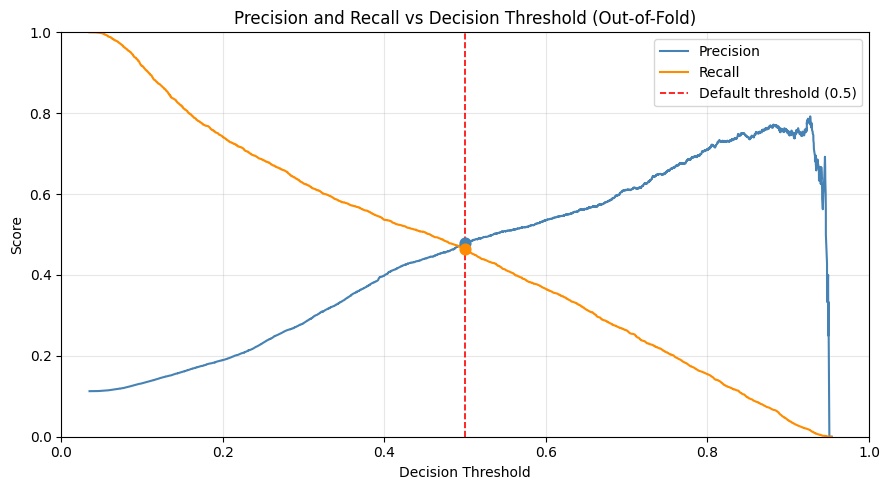

At threshold 0.5 -- Precision: 0.479, Recall: 0.463


In [52]:
# Use the out-of-fold probabilities already computed in Part D
# precision_recall_curve returns arrays indexed by threshold
precisions, recalls, thresholds = precision_recall_curve(y_train_arr, oof_proba_pos)

# Find the index where threshold is closest to 0.5
idx_05 = (abs(thresholds - 0.5)).argmin()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='darkorange')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.2, label='Default threshold (0.5)')
ax.scatter([thresholds[idx_05]], [precisions[idx_05]], color='steelblue', zorder=5, s=60)
ax.scatter([thresholds[idx_05]], [recalls[idx_05]], color='darkorange', zorder=5, s=60)

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall vs Decision Threshold (Out-of-Fold)')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'At threshold 0.5 -- Precision: {precisions[idx_05]:.3f}, Recall: {recalls[idx_05]:.3f}')

##### 5.1 Threshold Direction

The precision-recall curve above shows the classic trade-off: as the threshold decreases (moving left), recall increases while precision decreases, and vice versa.

**Why the threshold should be shifted lower than 0.5:**

The bank's two error types are not equally costly:

- A **False Negative** means the bank does not call a client who would have subscribed. This is a direct revenue loss of approximately $500 per missed client. Over a large campaign, this cost accumulates quickly and is difficult to recover because the opportunity has passed.

- A **False Positive** means the bank calls a client who does not subscribe. This costs agent time and the cost of the call. Even a moderately inefficient call centre operation keeps this cost well below $500 per call.

Given this asymmetry, the bank should prefer to err on the side of calling more clients (higher recall) even at the cost of more wasted calls (lower precision). Lowering the threshold below 0.5 achieves exactly this: it shifts more clients from "do not call" to "call", increasing the chance of catching real subscribers.

The exact optimal threshold would require knowing the precise cost ratio (FN cost divided by FP cost) and is outside the scope of this analysis. However, the direction is clear: the operating threshold should be **lower than 0.5**, likely in the range of 0.3 to 0.4, where the recall curve is still rising steeply but precision has not yet collapsed.

##### 5.2 Summary

| Question | Answer |
|---|---|
| Which error is more damaging? | False Negative (missed subscriber, ~$500 lost revenue) |
| Which error is less damaging? | False Positive (unnecessary call, well under $500 in cost) |
| Should threshold go higher or lower than 0.5? | Lower -- prioritise recall over precision |
| Suggested direction | Threshold in the range 0.3 to 0.4 |
| Rationale | At this range, recall gains from lowering the threshold remain large while precision loss remains manageable |

The model should be deployed with a threshold below 0.5 to serve as a call prioritisation tool that catches the majority of willing subscribers, accepting a moderate rate of unnecessary calls as the cost of not missing real business opportunities.

### 6. Final Evaluation on Hold-out Test Set

All model selection, ablation experiments, and hyperparameter tuning in Parts A-C were performed exclusively on `X_train` using cross-validation. The test set (`X_test`, `y_test`) has been held out until this point and is evaluated exactly once below, providing an unbiased estimate of real-world performance.

##### 6.1 Results

The confusion matrix and performance metrics below reflect predictions made by the final tuned champion pipeline on data it has never seen during any stage of training or model selection.

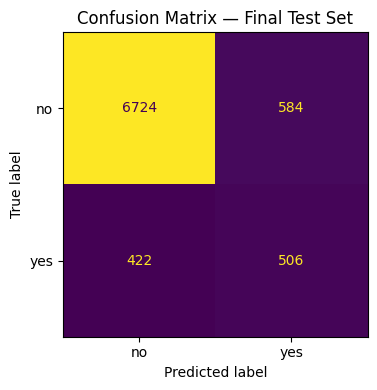

,Class,Accuracy,Precision,Recall,F1 Score
0,yes (subscriber),0.8779,0.4642,0.5453,0.5015


In [53]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Fit the final tuned champion on the full training set
pipeline.fit(X_train, y_train)

# Evaluate on the test set — this is run exactly once
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Final Test Set')
plt.tight_layout()
plt.show()

# Summary metrics table
results = pd.DataFrame([{
    'Class':     'yes (subscriber)',
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1 Score':  round(f1_score(y_test, y_pred), 4),
}])
display(results)